# F1 Race Strategy — Model Comparison Lab

เปรียบเทียบอัลกอริทึม Machine Learning 5 ตัวสำหรับทำนายเวลาต่อรอบ (Lap Time) และใช้วางกลยุทธ์การเข้าพิท
โดยใช้ pipeline การเตรียมข้อมูลและ feature เดียวกันกับโปรเจกต์หลัก (`F1-RaceOpt-AI-Strategy`) เพื่อให้ผลเทียบกันได้ตรงๆ

**อัลกอริทึมที่เทียบ:**
1. `RandomForestRegressor` (โมเดล baseline ที่ใช้อยู่ใน `model.pkl` ปัจจุบัน)
2. `ExtraTreesRegressor`
3. `HistGradientBoostingRegressor`
4. `XGBRegressor` (XGBoost)
5. `CatBoostRegressor`

**3 หัวข้อหลักที่ประเมิน** (อิงตามสิ่งที่หน้า Forecast ของโปรเจกต์หลักต้องพยากรณ์จริง: เวลารวมทั้งเรซ → อันดับ → win probability):

| หัวข้อ | คำถามที่ตอบ | วิธีวัด |
|---|---|---|
| **1. ความแม่นของค่าพยากรณ์ตัวเลข**<br>(Point-forecast Accuracy) | โมเดลทำนายเวลาต่อรอบ / เวลารวมทั้งเรซแม่นแค่ไหน | GroupKFold MAE / RMSE / R² แบบ out-of-fold (กันข้อมูลรั่วข้าม race) + %Δ ของเวลารวมเทียบเวลาจริงบน holdout races |
| **2. ความแม่นของอันดับ**<br>(Ranking Accuracy) | โมเดลจัดอันดับผู้เข้าเส้นชัยถูกไหม ไม่ใช่แค่ตัวเลขเวลา | จำลองทั้งสนาม (20 คัน) บน holdout race แล้ววัด winner-hit-rate, Top-3 overlap, Spearman rank correlation เทียบผลจริง |
| **3. ความน่าเชื่อถือของ Win Probability**<br>(Calibration) | เมื่อโมเดลบอกว่าคันไหนมีโอกาสชนะกี่ % ตัวเลขนั้นน่าเชื่อถือแค่ไหน | Brier score ของ win probability (softmax ของเวลารวมทั้งสนาม) เทียบผู้ชนะจริงบน holdout races |

> รันเซลล์ตามลำดับบน Google Colab (Runtime → Run all). เซลล์แรกจะติดตั้ง dependency ที่จำเป็น (fastf1, xgboost, catboost) และดึงข้อมูล lap จริงจาก FastF1 API (ต้องมีอินเทอร์เน็ต ครั้งแรกจะช้าเพราะโหลด/แคชข้อมูล)

## 0. ติดตั้ง Dependencies

In [23]:
import platform

if platform.system() == "Linux":
    !apt-get -qq install -y fonts-thai-tlwg > /dev/null 2>&1

!pip install -q fastf1 xgboost catboost scikit-learn==1.9.0 pandas numpy matplotlib
print("done")


done



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import os
import time
import pickle
import subprocess
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from itertools import product

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import fastf1
from fastf1.exceptions import RateLimitExceededError

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── ตั้งฟอนต์ไทยให้ matplotlib (ไม่งั้นตัวอักษรไทยในกราฟจะขึ้นเป็นสี่เหลี่ยม/ตัวไม่แสดง) ──
# บน Colab (Linux): ต้องรันเซลล์ "0. ติดตั้ง Dependencies" ก่อน (ติดตั้ง fonts-thai-tlwg ผ่าน apt-get แล้ว)
# บนเครื่อง local (Windows/Mac): ใช้ฟอนต์ไทยที่มากับระบบอยู่แล้วโดยไม่ต้องติดตั้งเพิ่ม
_thai_font_name = None
try:
    if platform.system() == "Linux":
        _found = subprocess.run(["fc-list", ":lang=th", "file"], capture_output=True, text=True).stdout
        for _path in _found.strip().split("\n"):
            _path = _path.strip().rstrip(":")
            if not _path:
                continue
            fm.fontManager.addfont(_path)
            _thai_font_name = fm.FontProperties(fname=_path).get_name()
    else:
        # ฟอนต์ที่รองรับภาษาไทยซึ่งมักติดตั้งมากับ Windows/Mac อยู่แล้ว
        _candidates = ["Tahoma", "Leelawadee UI", "Angsana New", "Cordia New", "Browallia New",
                       "Thonburi", "Ayuthaya"]
        _installed = {f.name for f in fm.fontManager.ttflist}
        for _candidate in _candidates:
            if _candidate in _installed:
                _thai_font_name = _candidate
                break
except Exception as e:
    print(f"ตั้งฟอนต์ไทยไม่สำเร็จ: {e}")

if _thai_font_name:
    plt.rcParams["font.family"] = _thai_font_name
    print(f"ใช้ฟอนต์กราฟ: {_thai_font_name}")
else:
    print("ไม่พบฟอนต์ไทยที่ติดตั้ง — กราฟจะใช้ข้อความภาษาอังกฤษล้วนแทน ไม่มีผลอะไร")
plt.rcParams["axes.unicode_minus"] = False


ใช้ฟอนต์กราฟ: Tahoma


## 1. Data Pipeline

ใช้ logic เดียวกับ `data_pipeline.py` ของโปรเจกต์หลัก: โหลด lap ของแต่ละคู่ (year, gp, driver) จาก FastF1,
สร้าง feature (TyreLife, FuelEst, StintLap, PitStopsSoFar, one-hot ของ Compound/TrackStatus ฯลฯ) แล้ว cache ลงดิสก์

เพิ่มฟังก์ชัน `load_race_field_results()` สำหรับดึง "อันดับเข้าเส้นชัยจริงทั้งสนาม" จาก `session.results` ของ FastF1 —
ใช้เป็น ground truth ของหัวข้อที่ 2 (Ranking) และหัวข้อที่ 3 (Calibration) ด้านล่าง

In [25]:
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CACHE_ROOT = "/content/drive/MyDrive/f1_raceopt_cache"
except ImportError:
    # ไม่ได้รันบน Colab (เช่นรัน local ผ่าน VS Code) — ใช้โฟลเดอร์ในเครื่องแทน ซึ่งอยู่ถาวรอยู่แล้ว
    CACHE_ROOT = "./cache"
except Exception as e:
    print(f"Mount Google Drive ไม่สำเร็จ ({e}) — ใช้ cache ชั่วคราวใน Colab แทน "
          f"(จะหายทุกครั้งที่ runtime รีสตาร์ทเต็มรูปแบบ และต้องดึงข้อมูลจาก FastF1 ใหม่หมด เสี่ยงโดน rate limit ซ้ำ)")
    CACHE_ROOT = "./cache"
os.makedirs(CACHE_ROOT, exist_ok=True)
print(f"ใช้ CACHE_ROOT = {CACHE_ROOT}")

FASTF1_LOAD_ATTEMPTS = 3
FASTF1_RETRY_DELAY_SEC = 8


def _load_fastf1_session(year, gp):
    """fastf1.get_session(...).load() พร้อม retry — บาง session ดึงข้อมูลจาก server จริงล้มเหลวชั่วคราว
    (primary source / livetiming mirror ล่ม) ลองใหม่สัก 2-3 ครั้งก่อนค่อยยอมแพ้
    ยกเว้น RateLimitExceededError (โดน rate limit 500 เรียก/ชม. ของ FastF1 เอง) — กรณีนี้ retry ทันที
    ไม่ช่วยอะไรเพราะ quota นับเป็นรายชั่วโมง จึงโยน error ออกไปทันทีไม่เสีย attempt"""
    ff1_cache_dir = os.path.join(CACHE_ROOT, f"{year}_{gp.replace(' ', '_')}")
    os.makedirs(ff1_cache_dir, exist_ok=True)
    fastf1.Cache.enable_cache(ff1_cache_dir)

    last_err = None
    for attempt in range(1, FASTF1_LOAD_ATTEMPTS + 1):
        try:
            session = fastf1.get_session(year, gp, "R")
            session.load()
            if session.laps is None or session.laps.empty:
                raise ValueError("session.laps ว่างเปล่าหลัง load()")
            return session
        except RateLimitExceededError:
            raise
        except Exception as e:
            last_err = e
            print(f"    โหลด session {gp} {year} ล้มเหลว (ครั้งที่ {attempt}/{FASTF1_LOAD_ATTEMPTS}): {e}")
            if attempt < FASTF1_LOAD_ATTEMPTS:
                time.sleep(FASTF1_RETRY_DELAY_SEC)

    raise RuntimeError(f"โหลด session {gp} {year} ไม่สำเร็จหลังลอง {FASTF1_LOAD_ATTEMPTS} ครั้ง: {last_err}")


def load_race_laps(year=2023, gp="Bahrain", driver="VER"):
    cache_key = f"{year}_{gp}_{driver}".replace(" ", "_")
    cache_path = os.path.join(CACHE_ROOT, f"{cache_key}.pkl")

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    session = _load_fastf1_session(year, gp)
    laps = session.laps.pick_driver(driver).reset_index(drop=True)

    laps["LapTimeSec"] = laps["LapTime"].dt.total_seconds()
    laps["Sector1Sec"] = laps["Sector1Time"].dt.total_seconds()
    laps["Sector2Sec"] = laps["Sector2Time"].dt.total_seconds()
    laps["Sector3Sec"] = laps["Sector3Time"].dt.total_seconds()

    laps = laps[~laps["LapTimeSec"].isna() & ~laps["LapNumber"].isna()].copy()
    laps = laps.reset_index(drop=True)

    if laps.empty:
        raise ValueError(f"ไม่พบ lap ของ {driver} ใน {gp} {year}")

    total_laps = int(laps["LapNumber"].max())
    laps["FuelEst"] = (total_laps - laps["LapNumber"]) / total_laps

    if "Stint" in laps.columns:
        laps["StintNumber"] = laps["Stint"].ffill().fillna(1).astype(int)
    else:
        laps["StintNumber"] = 1

    laps["StintLap"] = laps.groupby("StintNumber").cumcount() + 1
    laps["PitStopsSoFar"] = laps["StintNumber"] - 1
    laps["IsOutLap"] = laps["PitOutTime"].notna().astype(int)
    laps["IsInLap"] = laps["PitInTime"].notna().astype(int)

    if "TrackStatus" not in laps.columns:
        laps["TrackStatus"] = 1
    laps["TrackStatus"] = laps["TrackStatus"].fillna(1).astype(int)
    laps["TyreLife"] = laps["TyreLife"].fillna(0) if "TyreLife" in laps.columns else 0

    if "Position" in laps.columns:
        laps["Position"] = laps["Position"].ffill().fillna(1)
    else:
        laps["Position"] = 1

    base_cols = [
        "LapNumber", "LapTimeSec", "Compound", "TyreLife", "TrackStatus",
        "Position", "Sector1Sec", "Sector2Sec", "Sector3Sec",
        "FuelEst", "StintNumber", "StintLap", "PitStopsSoFar",
        "IsOutLap", "IsInLap",
    ]
    base_cols = [c for c in base_cols if c in laps.columns]
    data = laps[base_cols].copy()

    data = pd.get_dummies(
        data,
        columns=[c for c in ["Compound", "TrackStatus"] if c in data.columns],
        drop_first=False,
    )

    meta = {"year": year, "gp": gp, "driver": driver, "total_laps": total_laps}

    with open(cache_path, "wb") as f:
        pickle.dump((data, meta), f)

    return data, meta


def load_multi_race_laps(race_driver_list):
    all_data, all_meta = [], []
    for year, gp, driver in race_driver_list:
        try:
            print(f"  loading {driver} @ {gp} {year} ...")
            data, meta = load_race_laps(year, gp, driver)
            data["DriverCode"] = driver
            data["RaceYear"] = year
            data["GP_Label"] = gp
            all_data.append(data)
            all_meta.append(meta)
            print(f"    ok: {len(data)} laps")
        except RateLimitExceededError:
            print(f"    หยุดโหลด: โดน FastF1 rate limit (500 เรียก/ชม.) — รอสักครู่แล้วรันใหม่")
            break
        except Exception as e:
            print(f"    skip {driver} @ {gp} {year}: {e}")

    if not all_data:
        raise ValueError("ไม่สามารถโหลดข้อมูลได้เลย")

    combined = pd.concat(all_data, ignore_index=True)
    combined = pd.get_dummies(combined, columns=["DriverCode", "GP_Label"], drop_first=False)
    return combined, all_meta


def load_race_field_results(year, gp):
    """คืนอันดับเข้าเส้นชัยจริงทั้งสนาม (list ของ driver code เรียงจากที่ 1) จาก session.results ของ FastF1
    ใช้เป็น ground truth สำหรับหัวข้อที่ 2 (Ranking) และหัวข้อที่ 3 (Calibration)"""
    cache_key = f"results_{year}_{gp}".replace(" ", "_")
    cache_path = os.path.join(CACHE_ROOT, f"{cache_key}.pkl")

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    session = _load_fastf1_session(year, gp)

    res = session.results[["Abbreviation", "Position"]].dropna()
    res = res[res["Position"] > 0]
    finishing_order = res.sort_values("Position")["Abbreviation"].tolist()

    with open(cache_path, "wb") as f:
        pickle.dump(finishing_order, f)

    return finishing_order


ใช้ CACHE_ROOT = ./cache


In [26]:
# เหมือนกับ TRAIN_COMBINATIONS ใน train_model_advanced.py
TRAIN_COMBINATIONS = [
    (2023, "Bahrain", "VER"),
    (2023, "Bahrain", "HAM"),
    (2023, "Bahrain", "LEC"),
    (2023, "Bahrain", "ALO"),
    (2023, "Saudi Arabia", "VER"),
    (2023, "Saudi Arabia", "PER"),
    (2023, "Australia", "VER"),
    (2023, "Australia", "HAM"),
    (2022, "Bahrain", "LEC"),
    (2022, "Bahrain", "VER"),
]

# สนามที่ "ไม่เคย" อยู่ใน TRAIN_COMBINATIONS เลย ใช้เป็น held-out สำหรับทั้ง 3 หัวข้อประเมินด้านล่าง
# (ตั้งตาม AVAILABLE_RACES ของ data_pipeline.py — เพิ่ม/เปลี่ยนสนามได้ตามต้องการ)
HOLDOUT_RACES = [
    (2023, "Monaco"),
    (2023, "British"),
    (2023, "Italian"),
]

print("=== โหลดข้อมูลเทรน (multi-race) ===")
combined_data, all_meta = load_multi_race_laps(TRAIN_COMBINATIONS)
print(f"\nรวม {len(combined_data)} laps จาก {len(all_meta)} combinations")


=== โหลดข้อมูลเทรน (multi-race) ===
  loading VER @ Bahrain 2023 ...
    ok: 57 laps
  loading HAM @ Bahrain 2023 ...
    ok: 57 laps
  loading LEC @ Bahrain 2023 ...
    ok: 39 laps
  loading ALO @ Bahrain 2023 ...
    ok: 57 laps
  loading VER @ Saudi Arabia 2023 ...
    ok: 48 laps
  loading PER @ Saudi Arabia 2023 ...
    ok: 48 laps
  loading VER @ Australia 2023 ...
    ok: 52 laps
  loading HAM @ Australia 2023 ...
    ok: 53 laps
  loading LEC @ Bahrain 2022 ...
    ok: 54 laps
  loading VER @ Bahrain 2022 ...
    ok: 53 laps

รวม 518 laps จาก 10 combinations


In [27]:
y = combined_data["LapTimeSec"].values
X = combined_data.drop(columns=["LapTimeSec", "Sector1Sec", "Sector2Sec", "Sector3Sec"], errors="ignore")
X = X.select_dtypes(include=[np.number, "bool"]).astype(float)
feature_cols = X.columns.tolist()

print(f"จำนวนรอบทั้งหมด: {len(X)}, จำนวน feature: {len(feature_cols)}")


จำนวนรอบทั้งหมด: 518, จำนวน feature: 20


## 2. โมเดลที่จะเทียบ

ตั้งค่า hyperparameter ให้ "ระดับความจุ" (capacity) ใกล้เคียงกันที่สุดเท่าที่ทำได้ (จำนวน tree/iteration ~500, depth ใกล้เคียงกัน)
เพื่อให้การเทียบยุติธรรม ไม่ใช่การเทียบ "โมเดลที่จูนมาดีกว่า" กับ "โมเดล default"

In [28]:
MODELS = {
    "RandomForest": RandomForestRegressor(
        n_estimators=500, max_depth=16, min_samples_split=3, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500, max_depth=16, min_samples_split=3, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=500, max_depth=16, learning_rate=0.05, random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500, max_depth=8, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=500, depth=8, learning_rate=0.05,
        random_seed=RANDOM_STATE, verbose=False,
    ),
}
list(MODELS.keys())


['RandomForest', 'ExtraTrees', 'HistGradientBoosting', 'XGBoost', 'CatBoost']

## 3. Utility — จำลองกลยุทธ์ pit stop และจำลองทั้งสนาม

ใช้ logic เดียวกับ `strategy_optimizer.py` (grid search compound + pit lap แบบ 1-stop) และ `race_simulator.py`
(`DRIVER_PACE` = pace offset คงที่ต่อคัน) ของโปรเจกต์หลัก เพื่อจำลอง "ทั้งสนาม 20 คัน" ให้ใกล้เคียงกับสิ่งที่หน้า Forecast
ของแอปจริงคำนวณ แล้วนำผลไปใช้ร่วมกันในหัวข้อที่ 1, 2 และ 3 ด้านล่าง

In [29]:
PIT_LOSS = 22.0

# เหมือนกับ race_simulator.py ของโปรเจกต์หลัก: pace offset คงที่ต่อคัน บวกเข้ากับเวลาที่โมเดลทำนาย
# ใช้แยกฝีมือ/ฟอร์มรถของนักแข่งที่ "ไม่มี" ใน TRAIN_COMBINATIONS เลย (โมเดลเองแยกไม่ออกจาก one-hot)
DRIVER_PACE = {
    "VER": 0.0,  "PER": 0.30, "ALO": 0.70,  "HAM": 0.90,
    "SAI": 1.00, "RUS": 1.05, "LEC": 0.80,  "STR": 1.40,
    "NOR": 1.20, "PIA": 1.30, "GAS": 1.60,  "OCO": 1.60,
    "BOT": 1.80, "ZHO": 1.90, "HUL": 2.00,  "MAG": 2.10,
    "ALB": 2.20, "SAR": 2.40, "TSU": 2.10,  "DEV": 2.50,
}


def compound_one_hot(comp):
    comp = comp.upper()
    return {
        "Compound_SOFT": 1 if comp == "SOFT" else 0,
        "Compound_MEDIUM": 1 if comp == "MEDIUM" else 0,
        "Compound_HARD": 1 if comp == "HARD" else 0,
    }


def simulate_strategy_batch(model, feature_cols, total_laps, strategies,
                              driver_code=None, gp_label=None, race_year=None):
    """จำลองกลยุทธ์ 1-stop หลายชุดพร้อมกัน (batch predict ครั้งเดียว) — เหมือน strategy_optimizer.py"""
    rows, segments = [], []
    for c1, c2, pit_lap in strategies:
        stint, pit_stops, compound = 1, 0, c1.upper()
        strategy_rows, penalties = [], []
        for lap in range(1, total_laps + 1):
            pit_penalty = 0.0
            if lap == pit_lap:
                pit_stops += 1; stint = 2; compound = c2.upper(); tyre_life = 1; pit_penalty = PIT_LOSS
            elif stint == 1:
                tyre_life = lap
            else:
                tyre_life = lap - pit_lap + 1

            feat = {f: 0.0 for f in feature_cols}
            feat.update({
                "LapNumber": lap, "TyreLife": tyre_life,
                "FuelEst": (total_laps - lap) / total_laps,
                "StintNumber": stint, "StintLap": tyre_life,
                "PitStopsSoFar": pit_stops,
                "IsInLap": 1 if pit_penalty > 0 else 0, "IsOutLap": 0,
                "TrackStatus_1": 1, "Position": 1,
            })
            feat.update(compound_one_hot(compound))
            if driver_code and f"DriverCode_{driver_code}" in feat:
                feat[f"DriverCode_{driver_code}"] = 1
            if gp_label and f"GP_Label_{gp_label}" in feat:
                feat[f"GP_Label_{gp_label}"] = 1
            if race_year is not None and "RaceYear" in feat:
                feat["RaceYear"] = race_year
            strategy_rows.append(feat)
            penalties.append(pit_penalty)
        rows.extend(strategy_rows)
        segments.append(penalties)

    predicted = model.predict(pd.DataFrame(rows, columns=feature_cols))
    results, offset = [], 0
    for penalties in segments:
        n = len(penalties)
        results.append(sum(float(t) + p for t, p in zip(predicted[offset:offset + n], penalties)))
        offset += n
    return results


def simulate_strategy_single(model, feature_cols, total_laps, first_compound, second_compound, pit_lap,
                               driver_code=None, gp_label=None, race_year=None):
    """จำลองกลยุทธ์เดียว (ไม่ grid search) — ใช้เป็น baseline วัดหัวข้อที่ 1"""
    return simulate_strategy_batch(
        model, feature_cols, total_laps,
        [(first_compound, second_compound, pit_lap)],
        driver_code=driver_code, gp_label=gp_label, race_year=race_year,
    )[0]


def grid_search_strategies(model, feature_cols, total_laps, driver_code=None, gp_label=None, race_year=None):
    """หากลยุทธ์ 1-stop ที่ดีที่สุด (sim_total ต่ำสุด) — เหมือน strategy_optimizer.py"""
    compounds = ["SOFT", "MEDIUM", "HARD"]
    pit_laps = list(range(max(5, int(total_laps * 0.20)), min(total_laps - 5, int(total_laps * 0.55)) + 1, 2))

    specs = [(c1, c2, pit) for c1, c2, pit in product(compounds, compounds, pit_laps) if c1 != c2]

    sims = simulate_strategy_batch(model, feature_cols, total_laps, specs,
                                     driver_code=driver_code, gp_label=gp_label, race_year=race_year)
    results = [{"first_compound": c1, "second_compound": c2, "pit_lap": pit, "sim_total": sim}
               for (c1, c2, pit), sim in zip(specs, sims)]
    results.sort(key=lambda r: r["sim_total"])
    return results


def race_day_offset(model, feature_cols, total_laps, real_ver_total, gp_label=None, race_year=None):
    """ชดเชย bias ของแต่ละสนาม/แต่ละโมเดล โดยเทียบ VER กลยุทธ์ baseline (MEDIUM→SOFT@44%) กับเวลาจริง
    — logic เดียวกับ forecast_page() ใน app.py"""
    ver_sim_raw = simulate_strategy_single(
        model, feature_cols, total_laps, "MEDIUM", "SOFT", int(total_laps * 0.44),
        driver_code="VER", gp_label=gp_label, race_year=race_year,
    )
    return (real_ver_total - ver_sim_raw) / total_laps


def simulate_full_field(model, feature_cols, total_laps, driver_codes, global_offset,
                          gp_label=None, race_year=None):
    """จำลองทั้งสนาม: หากลยุทธ์ 1-stop ที่ดีที่สุดให้แต่ละคัน แล้วบวก pace offset + global_offset
    คืนค่า dict {driver_code: predicted_total_time}"""
    field = {}
    for code in driver_codes:
        best = grid_search_strategies(model, feature_cols, total_laps,
                                        driver_code=code, gp_label=gp_label, race_year=race_year)[0]
        pace_offset = DRIVER_PACE.get(code, 1.5) + global_offset
        field[code] = best["sim_total"] + pace_offset * total_laps
    return field


## 4. หัวข้อที่ 1 — ความแม่นของค่าพยากรณ์ตัวเลข (Point-forecast Accuracy)

วัด 2 ระดับ:
- **ระดับรอบ (lap-level)**: MAE / RMSE / R² ของเวลาต่อรอบ ด้วย `GroupKFold` แบ่งตาม (year, gp, driver) แบบ out-of-fold
  (แต่ละ race/driver ถูกกันออกไปเป็น test ทั้งชุด ไม่ใช่สุ่มรายรอบ เพื่อไม่ให้ข้อมูลรั่วระหว่าง train/test)
- **ระดับทั้งเรซ (race-level)**: จำลองกลยุทธ์ baseline เดียวกัน (MEDIUM→SOFT เข้าพิทที่ 44% ของสนาม) แล้วเทียบเวลารวม
  ที่โมเดลทำนายกับเวลารวมจริงของ VER บน holdout races — วัดเป็น %Δ (ไม่ผ่านการปรับ offset ใดๆ เพื่อดู bias ดิบของโมเดล)

In [30]:
trained_models = {}
train_time_rows = []

for name, model in MODELS.items():
    print(f"--- fit {name} บนข้อมูลเทรนทั้งหมด ({len(X)} laps) ---")
    t0 = time.perf_counter()
    model.fit(X, y)
    train_time = time.perf_counter() - t0
    trained_models[name] = model
    train_time_rows.append({"model": name, "train_time_sec": train_time})
    print(f"  train_time={train_time:.2f}s")

train_time_df = pd.DataFrame(train_time_rows).set_index("model")
train_time_df


--- fit RandomForest บนข้อมูลเทรนทั้งหมด (518 laps) ---
  train_time=0.40s
--- fit ExtraTrees บนข้อมูลเทรนทั้งหมด (518 laps) ---
  train_time=0.25s
--- fit HistGradientBoosting บนข้อมูลเทรนทั้งหมด (518 laps) ---
  train_time=0.41s
--- fit XGBoost บนข้อมูลเทรนทั้งหมด (518 laps) ---
  train_time=0.24s
--- fit CatBoost บนข้อมูลเทรนทั้งหมด (518 laps) ---
  train_time=1.08s


,train_time_sec
model,
RandomForest,0.404513
ExtraTrees,0.247429
HistGradientBoosting,0.409483
XGBoost,0.244236
CatBoost,1.077352


In [31]:
# สร้าง group id (year_gp_driver) จาก one-hot ของ GP_Label / DriverCode เพื่อใช้กับ GroupKFold
gp_cols = [c for c in combined_data.columns if c.startswith("GP_Label_")]
driver_cols = [c for c in combined_data.columns if c.startswith("DriverCode_")]
gp_series = combined_data.loc[X.index, gp_cols].idxmax(axis=1)
driver_series = combined_data.loc[X.index, driver_cols].idxmax(axis=1)
groups = combined_data.loc[X.index, "RaceYear"].astype(str) + "_" + gp_series + "_" + driver_series

n_groups = groups.nunique()
gkf = GroupKFold(n_splits=min(5, n_groups))

accuracy_rows = []
for name, model_template in MODELS.items():
    y_pred_oof = np.zeros(len(y))
    filled = np.zeros(len(y), dtype=bool)

    for train_idx, test_idx in gkf.split(X, y, groups=groups):
        m = type(model_template)(**model_template.get_params())
        m.fit(X.iloc[train_idx], y[train_idx])
        y_pred_oof[test_idx] = m.predict(X.iloc[test_idx])
        filled[test_idx] = True

    mae = mean_absolute_error(y[filled], y_pred_oof[filled])
    rmse = np.sqrt(mean_squared_error(y[filled], y_pred_oof[filled]))
    r2 = r2_score(y[filled], y_pred_oof[filled])

    accuracy_rows.append({"model": name, "MAE_sec": mae, "RMSE_sec": rmse, "R2": r2})
    print(f"{name}: GroupKFold(out-of-fold) MAE={mae:.3f}s RMSE={rmse:.3f}s R2={r2:.4f}")

accuracy_df = pd.DataFrame(accuracy_rows).set_index("model")
accuracy_df


RandomForest: GroupKFold(out-of-fold) MAE=1.825s RMSE=4.649s R2=0.7919
ExtraTrees: GroupKFold(out-of-fold) MAE=3.134s RMSE=7.698s R2=0.4295
HistGradientBoosting: GroupKFold(out-of-fold) MAE=3.255s RMSE=5.770s R2=0.6795
XGBoost: GroupKFold(out-of-fold) MAE=2.073s RMSE=4.855s R2=0.7731
CatBoost: GroupKFold(out-of-fold) MAE=2.146s RMSE=4.704s R2=0.7870


,MAE_sec,RMSE_sec,R2
model,,,
RandomForest,1.825461,4.649156,0.791905
ExtraTrees,3.133520,7.697982,0.429485
HistGradientBoosting,3.254565,5.769609,0.679516
XGBoost,2.072523,4.854824,0.773087
CatBoost,2.146152,4.703937,0.786972


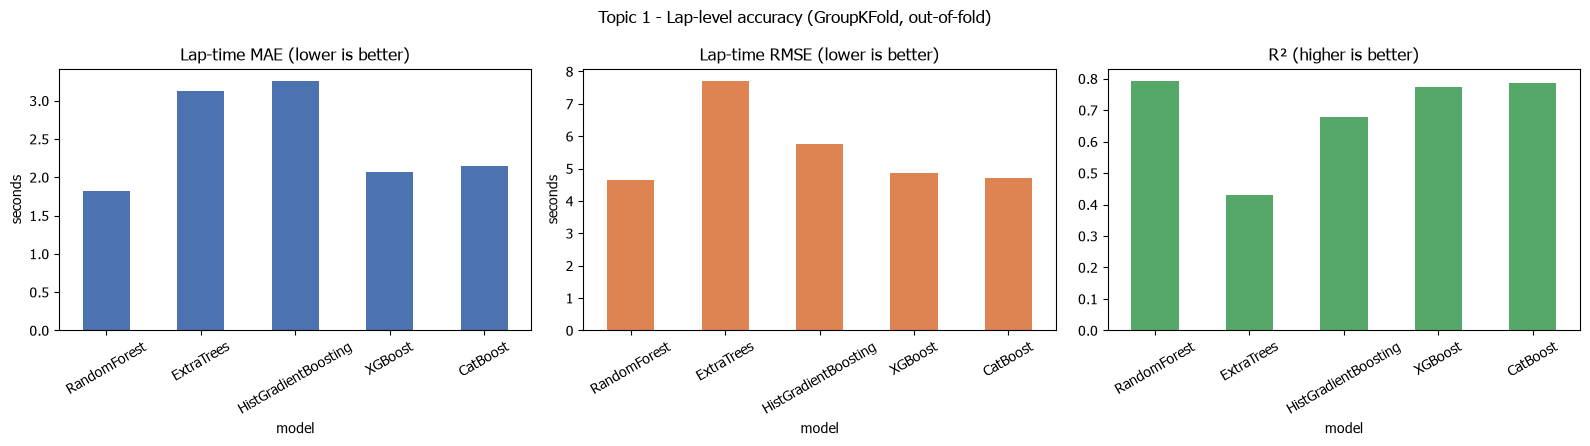

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

accuracy_df["MAE_sec"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Lap-time MAE (lower is better)")
axes[0].set_ylabel("seconds")

accuracy_df["RMSE_sec"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Lap-time RMSE (lower is better)")
axes[1].set_ylabel("seconds")

accuracy_df["R2"].plot(kind="bar", ax=axes[2], color="#55A868")
axes[2].set_title("R² (higher is better)")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Topic 1 - Lap-level accuracy (GroupKFold, out-of-fold)")
plt.tight_layout()
plt.show()


In [33]:
race_total_rows = []

for year, gp in HOLDOUT_RACES:
    print(f"=== โหลดผลจริง {gp} {year} (VER) เพื่อวัดเวลารวมทั้งเรซ ===")
    try:
        ver_data, ver_meta = load_race_laps(year, gp, "VER")
    except RateLimitExceededError:
        print("  หยุดทั้งลูป: โดน FastF1 rate limit (500 เรียก/ชม.) — รอสักครู่ (ปกติรอ ~1 ชม.) แล้วรันเซลล์นี้ใหม่")
        break
    except Exception as e:
        print(f"  ข้ามสนามนี้: โหลดข้อมูลไม่สำเร็จ ({e})")
        continue

    real_total = ver_data["LapTimeSec"].sum()
    total_laps = ver_meta["total_laps"]

    for name, model in trained_models.items():
        sim_total = simulate_strategy_single(
            model, feature_cols, total_laps, "MEDIUM", "SOFT", int(total_laps * 0.44),
            driver_code="VER", gp_label=gp, race_year=year,
        )
        delta_pct = (sim_total - real_total) / real_total * 100
        race_total_rows.append({
            "model": name, "gp": gp, "year": year,
            "real_total_sec": real_total, "sim_total_sec": sim_total,
            "delta_pct": delta_pct,
        })
        print(f"  {name}: sim={sim_total:.1f}s real={real_total:.1f}s delta={delta_pct:+.2f}%")

if not race_total_rows:
    raise RuntimeError("ไม่มี holdout race ไหนโหลดสำเร็จเลย — ตรวจการเชื่อมต่อ FastF1 แล้วรันเซลล์นี้ใหม่")

race_total_detail_df = pd.DataFrame(race_total_rows)
race_total_df = race_total_detail_df.groupby("model")["delta_pct"].agg(
    mean_abs_delta_pct=lambda s: s.abs().mean(),
    std_delta_pct="std",
)
race_total_df


=== โหลดผลจริง Monaco 2023 (VER) เพื่อวัดเวลารวมทั้งเรซ ===
  RandomForest: sim=7458.1s real=6532.0s delta=+14.18%
  ExtraTrees: sim=7497.1s real=6532.0s delta=+14.78%
  HistGradientBoosting: sim=7326.3s real=6532.0s delta=+12.16%
  XGBoost: sim=7287.4s real=6532.0s delta=+11.56%
  CatBoost: sim=7255.5s real=6532.0s delta=+11.08%
=== โหลดผลจริง British 2023 (VER) เพื่อวัดเวลารวมทั้งเรซ ===
  RandomForest: sim=4984.9s real=4938.5s delta=+0.94%
  ExtraTrees: sim=5006.5s real=4938.5s delta=+1.38%
  HistGradientBoosting: sim=4924.0s real=4938.5s delta=-0.29%
  XGBoost: sim=4882.1s real=4938.5s delta=-1.14%
  CatBoost: sim=4865.9s real=4938.5s delta=-1.47%
=== โหลดผลจริง Italian 2023 (VER) เพื่อวัดเวลารวมทั้งเรซ ===
  RandomForest: sim=4889.3s real=4333.2s delta=+12.83%
  ExtraTrees: sim=4911.0s real=4333.2s delta=+13.33%
  HistGradientBoosting: sim=4832.1s real=4333.2s delta=+11.51%
  XGBoost: sim=4790.5s real=4333.2s delta=+10.55%
  CatBoost: sim=4774.9s real=4333.2s delta=+10.19%


,mean_abs_delta_pct,std_delta_pct
model,,
CatBoost,7.579273,7.002012
ExtraTrees,9.828659,7.354263
HistGradientBoosting,7.988719,7.010561
RandomForest,9.316950,7.284853
XGBoost,7.752721,7.061692


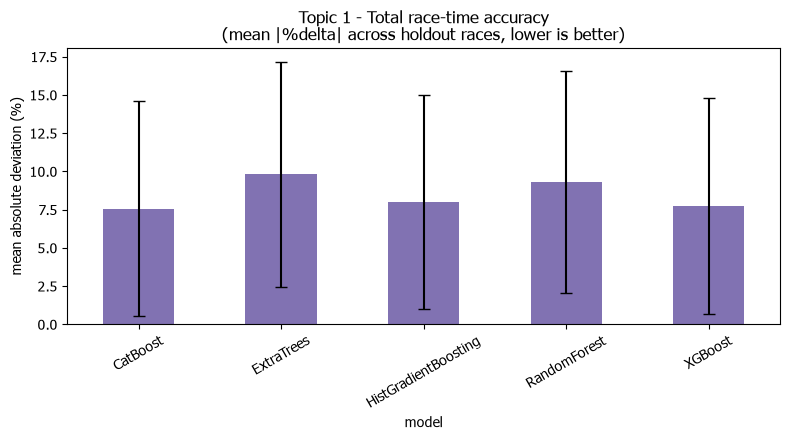

In [34]:
fig, ax = plt.subplots(figsize=(8, 4.5))
race_total_df["mean_abs_delta_pct"].plot(
    kind="bar", ax=ax, yerr=race_total_df["std_delta_pct"], color="#8172B2", capsize=4
)
ax.set_title("Topic 1 - Total race-time accuracy\n(mean |%delta| across holdout races, lower is better)")
ax.set_ylabel("mean absolute deviation (%)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

##ค่าเฉลี่ยของ "ส่วนต่างเวลารวมทั้งเรซ"

## 5. หัวข้อที่ 2 — ความแม่นของอันดับ (Ranking Accuracy)

จำลองทั้งสนาม 20 คัน (ใช้ `DRIVER_PACE` + กลยุทธ์ 1-stop ที่ดีที่สุดจาก grid search ต่อคัน) บนแต่ละ holdout race
แล้วเทียบอันดับที่โมเดลทำนายกับอันดับเข้าเส้นชัยจริงจาก FastF1:

- **winner_hit**: ทายผู้ชนะ (P1) ถูกไหม
- **top3_overlap**: กลุ่ม Top-3 ที่ทำนายซ้อนทับกับ Top-3 จริงกี่คัน (0-1)
- **spearman**: Spearman rank correlation ระหว่างอันดับที่ทำนายกับอันดับจริง (เฉพาะคันที่มีผลจริงให้เทียบ) — 1.0 = จัดอันดับตรงเป๊ะ

In [35]:
ranking_rows = []
field_sim_cache = {}       # (model_name, race_idx) -> {code: predicted_total_time}
actual_winner_by_race = {}  # race_idx -> driver code ที่ชนะจริง

for race_idx, (year, gp) in enumerate(HOLDOUT_RACES):
    print(f"\n=== Ranking evaluation: {gp} {year} ===")
    try:
        actual_order = load_race_field_results(year, gp)
        ver_data, ver_meta = load_race_laps(year, gp, "VER")
    except RateLimitExceededError:
        print("  หยุดทั้งลูป: โดน FastF1 rate limit (500 เรียก/ชม.) — รอสักครู่ (ปกติรอ ~1 ชม.) แล้วรันเซลล์นี้ใหม่")
        break
    except Exception as e:
        print(f"  ข้ามสนามนี้: โหลดข้อมูลไม่สำเร็จ ({e})")
        continue

    if not actual_order:
        print("  ข้ามสนามนี้: ไม่มีผลจริง (session.results ว่าง)")
        continue

    real_ver_total = ver_data["LapTimeSec"].sum()
    total_laps = ver_meta["total_laps"]

    actual_rank = {code: i for i, code in enumerate(actual_order, start=1)}
    actual_top3 = set(actual_order[:3])
    actual_winner = actual_order[0]
    actual_winner_by_race[race_idx] = actual_winner

    for name, model in trained_models.items():
        offset = race_day_offset(model, feature_cols, total_laps, real_ver_total, gp_label=gp, race_year=year)
        field = simulate_full_field(model, feature_cols, total_laps, list(DRIVER_PACE.keys()), offset,
                                      gp_label=gp, race_year=year)
        field_sim_cache[(name, race_idx)] = field

        predicted_order = sorted(field, key=lambda c: field[c])
        common = [c for c in predicted_order if c in actual_rank]
        predicted_top3 = set(predicted_order[:3])

        winner_hit = 1 if predicted_order[0] == actual_winner else 0
        top3_overlap = len(predicted_top3 & actual_top3) / 3

        if len(common) >= 3:
            pred_ranks = list(range(1, len(common) + 1))
            true_ranks = [actual_rank[c] for c in common]
            spearman_corr, _ = spearmanr(pred_ranks, true_ranks)
        else:
            spearman_corr = np.nan

        ranking_rows.append({
            "model": name, "gp": gp, "year": year,
            "predicted_winner": predicted_order[0], "actual_winner": actual_winner,
            "winner_hit": winner_hit, "top3_overlap": top3_overlap,
            "spearman": spearman_corr, "n_common_drivers": len(common),
        })
        print(f"  {name}: predicted P1={predicted_order[0]}  actual P1={actual_winner}  "
              f"winner_hit={bool(winner_hit)}  top3_overlap={top3_overlap:.2f}  spearman={spearman_corr:.2f}")

if not ranking_rows:
    raise RuntimeError("ไม่มี holdout race ไหนโหลดสำเร็จเลย — ตรวจการเชื่อมต่อ FastF1 แล้วรันเซลล์นี้ใหม่")

ranking_detail_df = pd.DataFrame(ranking_rows)
ranking_df = ranking_detail_df.groupby("model").agg(
    winner_hit_rate=("winner_hit", "mean"),
    mean_top3_overlap=("top3_overlap", "mean"),
    mean_spearman=("spearman", "mean"),
)
ranking_df



=== Ranking evaluation: Monaco 2023 ===
  RandomForest: predicted P1=VER  actual P1=VER  winner_hit=True  top3_overlap=0.67  spearman=0.62
  ExtraTrees: predicted P1=VER  actual P1=VER  winner_hit=True  top3_overlap=0.67  spearman=0.62
  HistGradientBoosting: predicted P1=VER  actual P1=VER  winner_hit=True  top3_overlap=0.33  spearman=0.58
  XGBoost: predicted P1=VER  actual P1=VER  winner_hit=True  top3_overlap=0.67  spearman=0.62
  CatBoost: predicted P1=VER  actual P1=VER  winner_hit=True  top3_overlap=0.33  spearman=0.58

=== Ranking evaluation: British 2023 ===
  RandomForest: predicted P1=VER  actual P1=VER  winner_hit=True  top3_overlap=0.33  spearman=0.65
  ExtraTrees: predicted P1=VER  actual P1=VER  winner_hit=True  top3_overlap=0.33  spearman=0.65
  HistGradientBoosting: predicted P1=VER  actual P1=VER  winner_hit=True  top3_overlap=0.33  spearman=0.64
  XGBoost: predicted P1=VER  actual P1=VER  winner_hit=True  top3_overlap=0.33  spearman=0.66
  CatBoost: predicted P1=VER

,winner_hit_rate,mean_top3_overlap,mean_spearman
model,,,
CatBoost,1.0,0.555556,0.652464
ExtraTrees,1.0,0.555556,0.665748
HistGradientBoosting,1.0,0.444444,0.654804
RandomForest,1.0,0.555556,0.667753
XGBoost,1.0,0.555556,0.668588


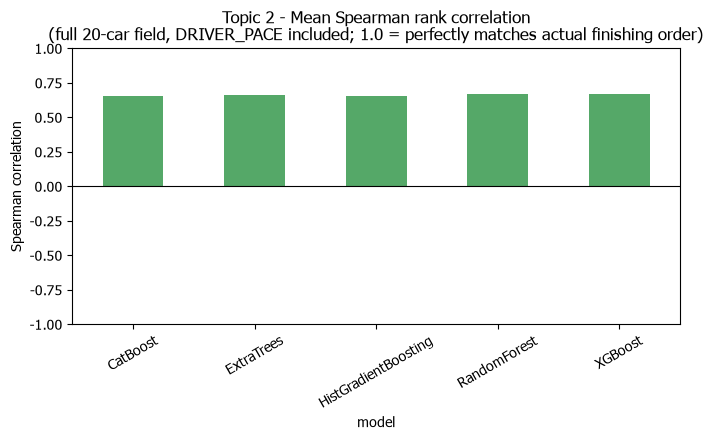

In [36]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ranking_df["mean_spearman"].plot(kind="bar", ax=ax, color="#55A868")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Topic 2 - Mean Spearman rank correlation\n(full 20-car field, DRIVER_PACE included; 1.0 = perfectly matches actual finishing order)")
ax.set_ylabel("Spearman correlation")
ax.set_ylim(-1, 1)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# หมายเหตุ: ตัดกราฟ "winner (P1) hit rate" ออกแล้ว เพราะ DRIVER_PACE["VER"]=0.0 (ต่ำสุดในกลุ่ม)
# ทำให้ VER ชนะการจำลองแทบทุกครั้งไม่ว่าจะใช้โมเดลไหน กราฟนั้นเลยแยกแยะโมเดลไม่ได้จริง
# (ดูหัวข้อ 5.1 ด้านล่างสำหรับเวอร์ชันที่ตัด DRIVER_PACE ออกแล้ววัดฝีมือโมเดลตรงๆ)


### 5.1 Model-only Ranking (ตัด `DRIVER_PACE` ออก วัดเฉพาะ signal ที่โมเดลเรียนรู้เองจริง)

`winner_hit_rate` ในหัวข้อ 5 ด้านบนแทบไม่ได้วัดฝีมือโมเดลเลย เพราะ `DRIVER_PACE["VER"] = 0.0` เป็นค่าต่ำสุดในดิกชันนารีทั้งหมด
คูณด้วยจำนวนรอบแล้วกลายเป็นช่องว่างหลายสิบวินาทีที่โมเดลพลิกกลับไม่ได้ — VER เลยชนะการจำลองแทบทุกครั้งไม่ว่าจะใช้โมเดลไหน

ที่นี่จะวัดใหม่แบบตัด baseline นี้ออก:
- **จำกัดเฉพาะ driver ที่โมเดลมีข้อมูลเทรนจริง** (มี one-hot `DriverCode_` ใน `feature_cols` — คือ VER/HAM/LEC/ALO/PER เท่านั้น)
- **ไม่บวก `DRIVER_PACE` เข้าไปเลย** ปล่อยให้ผลต่างของเวลามาจากสิ่งที่โมเดลเรียนรู้จาก feature (compound/tyre-deg/one-hot driver) ล้วนๆ
- วัดด้วย **winner_hit** (ทายคนที่ดีที่สุดในกลุ่มนี้ถูกไหม) และ **pairwise_concordance** (จากทุกคู่นักแข่งในกลุ่ม โมเดลจัดลำดับถูกทิศทางกี่ % — เหมาะกับกลุ่มตัวอย่างเล็กมากกว่า Spearman ที่ต้องใช้ข้อมูลเยอะกว่าถึงจะนิ่ง)

In [37]:
from itertools import combinations

KNOWN_DRIVERS = sorted(c.split("DriverCode_")[1] for c in feature_cols if c.startswith("DriverCode_"))
print("Driver ที่โมเดลมี one-hot จาก training data จริง:", KNOWN_DRIVERS)

known_ranking_rows = []
known_field_sim_cache = {}         # (model_name, race_idx) -> {code: predicted_total_time} (ไม่มี DRIVER_PACE)
known_actual_winner_by_race = {}   # race_idx -> driver code ที่ชนะจริงในกลุ่ม known driver

for race_idx, (year, gp) in enumerate(HOLDOUT_RACES):
    try:
        actual_order = load_race_field_results(year, gp)
        ver_data, ver_meta = load_race_laps(year, gp, "VER")
    except RateLimitExceededError:
        print("  หยุดทั้งลูป: โดน FastF1 rate limit (500 เรียก/ชม.) — รอสักครู่แล้วรันเซลล์นี้ใหม่")
        break
    except Exception as e:
        print(f"  ข้ามสนามนี้: โหลดข้อมูลไม่สำเร็จ ({e})")
        continue

    actual_known = [c for c in actual_order if c in KNOWN_DRIVERS]
    if len(actual_known) < 2:
        print(f"  ข้าม {gp} {year}: มี known driver ในผลจริงไม่ถึง 2 คัน")
        continue

    total_laps = ver_meta["total_laps"]
    real_ver_total = ver_data["LapTimeSec"].sum()
    known_actual_winner_by_race[race_idx] = actual_known[0]

    print(f"\n=== {gp} {year} — known drivers (อันดับจริง): {' > '.join(actual_known)} ===")

    for name, model in trained_models.items():
        offset = race_day_offset(model, feature_cols, total_laps, real_ver_total, gp_label=gp, race_year=year)

        # จำลองเฉพาะ driver ที่โมเดล "รู้จัก" จริงจาก training data — ไม่ใส่ DRIVER_PACE เลย
        # (offset ที่ใส่คือ bias ของทั้งสนาม เท่ากันทุกคัน ไม่กระทบอันดับสัมพัทธ์ระหว่าง driver)
        model_only_field = {}
        for code in actual_known:
            best = grid_search_strategies(model, feature_cols, total_laps,
                                            driver_code=code, gp_label=gp, race_year=year)[0]
            model_only_field[code] = best["sim_total"] + offset * total_laps
        known_field_sim_cache[(name, race_idx)] = model_only_field

        predicted_order = sorted(model_only_field, key=lambda c: model_only_field[c])

        pairs = list(combinations(actual_known, 2))
        correct_pairs = sum(
            1 for a, b in pairs
            if (predicted_order.index(a) < predicted_order.index(b))
            == (actual_known.index(a) < actual_known.index(b))
        )
        pairwise_concordance = correct_pairs / len(pairs) if pairs else np.nan
        winner_hit = 1 if predicted_order[0] == actual_known[0] else 0

        known_ranking_rows.append({
            "model": name, "gp": gp, "year": year,
            "n_known_drivers": len(actual_known),
            "winner_hit": winner_hit,
            "pairwise_concordance": pairwise_concordance,
        })
        print(f"  {name}: predicted={' > '.join(predicted_order)}  concordance={pairwise_concordance:.2f}")

if not known_ranking_rows:
    raise RuntimeError("ไม่มี holdout race ไหนมี known driver พอให้เทียบเลย")

known_ranking_detail_df = pd.DataFrame(known_ranking_rows)
known_ranking_df = known_ranking_detail_df.groupby("model").agg(
    winner_hit_rate=("winner_hit", "mean"),
    mean_pairwise_concordance=("pairwise_concordance", "mean"),
)
known_ranking_df


Driver ที่โมเดลมี one-hot จาก training data จริง: ['ALO', 'HAM', 'LEC', 'PER', 'VER']

=== Monaco 2023 — known drivers (อันดับจริง): VER > ALO > HAM > LEC > PER ===
  RandomForest: predicted=VER > PER > ALO > HAM > LEC  concordance=0.70
  ExtraTrees: predicted=VER > PER > ALO > HAM > LEC  concordance=0.70
  HistGradientBoosting: predicted=LEC > PER > VER > ALO > HAM  concordance=0.40
  XGBoost: predicted=VER > HAM > ALO > PER > LEC  concordance=0.80
  CatBoost: predicted=HAM > PER > VER > ALO > LEC  concordance=0.50

=== British 2023 — known drivers (อันดับจริง): VER > HAM > PER > ALO > LEC ===
  RandomForest: predicted=VER > PER > ALO > HAM > LEC  concordance=0.80
  ExtraTrees: predicted=VER > PER > ALO > HAM > LEC  concordance=0.80
  HistGradientBoosting: predicted=LEC > VER > PER > ALO > HAM  concordance=0.40
  XGBoost: predicted=VER > ALO > PER > HAM > LEC  concordance=0.70
  CatBoost: predicted=PER > HAM > VER > ALO > LEC  concordance=0.70

=== Italian 2023 — known drivers (อันดับ

,winner_hit_rate,mean_pairwise_concordance
model,,
CatBoost,0.0,0.600000
ExtraTrees,1.0,0.733333
HistGradientBoosting,0.0,0.500000
RandomForest,1.0,0.733333
XGBoost,1.0,0.733333


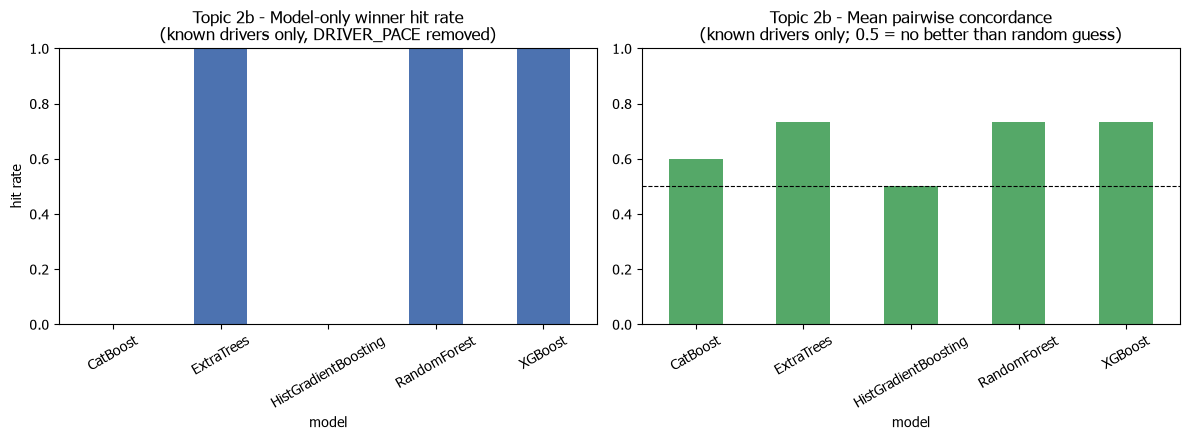

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

known_ranking_df["winner_hit_rate"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Topic 2b - Model-only winner hit rate\n(known drivers only, DRIVER_PACE removed)")
axes[0].set_ylabel("hit rate")
axes[0].set_ylim(0, 1)

known_ranking_df["mean_pairwise_concordance"].plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].axhline(0.5, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Topic 2b - Mean pairwise concordance\n(known drivers only; 0.5 = no better than random guess)")
axes[1].set_ylim(0, 1)

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 6. หัวข้อที่ 3 — ความน่าเชื่อถือของ Win Probability (Calibration)

แปลงเวลารวมที่จำลองได้ของแต่ละคัน (จากหัวข้อที่ 2) เป็น win probability ด้วย softmax เดียวกับที่หน้า Forecast ของแอปจริงใช้
(`compute_win_probabilities` ใน `race_simulator.py`) แล้ววัดว่า probability นั้น "น่าเชื่อถือ" แค่ไหนด้วย:

- **Brier score**: ค่าเฉลี่ยของ (probability ที่ให้แต่ละคัน − ผลจริง 0/1)² ทั้งสนาม ยิ่งต่ำยิ่งดี (0 = มั่นใจถูกต้องเป๊ะทุกครั้ง)
- **prob_assigned_to_actual_winner**: โมเดลให้ความน่าจะเป็นกับผู้ชนะจริงเฉลี่ยเท่าไหร่ ยิ่งสูงยิ่งดี

In [39]:
calibration_rows = []

for name in trained_models:
    for race_idx, (year, gp) in enumerate(HOLDOUT_RACES):
        key = (name, race_idx)
        if key not in field_sim_cache or race_idx not in actual_winner_by_race:
            continue
        field = field_sim_cache[key]
        actual_winner = actual_winner_by_race[race_idx]
        if actual_winner not in field:
            continue

        codes = list(field.keys())
        times = np.array([field[c] for c in codes])
        scores = -times
        exp = np.exp(scores - scores.max())
        probs = exp / exp.sum()
        win_prob = dict(zip(codes, probs))

        actual_one_hot = np.array([1.0 if c == actual_winner else 0.0 for c in codes])
        brier = float(np.mean((probs - actual_one_hot) ** 2))
        prob_on_actual_winner = float(win_prob[actual_winner])

        calibration_rows.append({
            "model": name, "gp": gp, "year": year,
            "brier_score": brier, "prob_assigned_to_actual_winner": prob_on_actual_winner,
        })
        print(f"{name} @ {gp} {year}: Brier={brier:.4f}  P(actual winner)={prob_on_actual_winner:.3f}")

calibration_detail_df = pd.DataFrame(calibration_rows)
calibration_df = calibration_detail_df.groupby("model").agg(
    mean_brier=("brier_score", "mean"),
    mean_prob_on_actual_winner=("prob_assigned_to_actual_winner", "mean"),
)
calibration_df


RandomForest @ Monaco 2023: Brier=0.0000  P(actual winner)=1.000
RandomForest @ British 2023: Brier=0.0000  P(actual winner)=1.000
RandomForest @ Italian 2023: Brier=0.0000  P(actual winner)=1.000
ExtraTrees @ Monaco 2023: Brier=0.0000  P(actual winner)=1.000
ExtraTrees @ British 2023: Brier=0.0000  P(actual winner)=1.000
ExtraTrees @ Italian 2023: Brier=0.0000  P(actual winner)=1.000
HistGradientBoosting @ Monaco 2023: Brier=0.0000  P(actual winner)=1.000
HistGradientBoosting @ British 2023: Brier=0.0000  P(actual winner)=1.000
HistGradientBoosting @ Italian 2023: Brier=0.0000  P(actual winner)=1.000
XGBoost @ Monaco 2023: Brier=0.0000  P(actual winner)=1.000
XGBoost @ British 2023: Brier=0.0000  P(actual winner)=1.000
XGBoost @ Italian 2023: Brier=0.0000  P(actual winner)=1.000
CatBoost @ Monaco 2023: Brier=0.0000  P(actual winner)=1.000
CatBoost @ British 2023: Brier=0.0000  P(actual winner)=1.000
CatBoost @ Italian 2023: Brier=0.0000  P(actual winner)=0.999


,mean_brier,mean_prob_on_actual_winner
model,,
CatBoost,1.892104e-08,0.999657
ExtraTrees,1.436815e-17,1.000000
HistGradientBoosting,1.317128e-16,1.000000
RandomForest,5.703750e-18,1.000000
XGBoost,1.551842e-17,1.000000


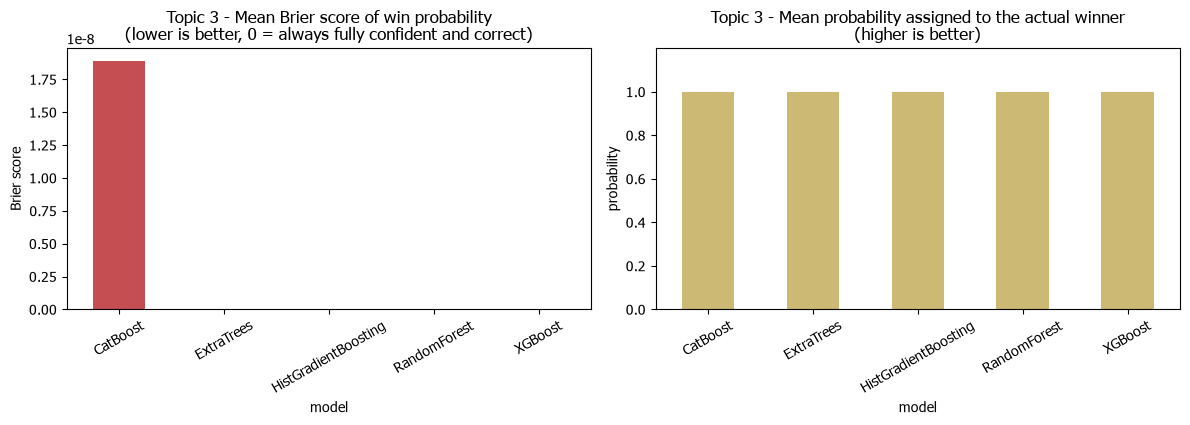

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

calibration_df["mean_brier"].plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("Topic 3 - Mean Brier score of win probability\n(lower is better, 0 = always fully confident and correct)")
axes[0].set_ylabel("Brier score")

calibration_df["mean_prob_on_actual_winner"].plot(kind="bar", ax=axes[1], color="#CCB974")
axes[1].set_title("Topic 3 - Mean probability assigned to the actual winner\n(higher is better)")
axes[1].set_ylabel("probability")
axes[1].set_ylim(0, max(0.3, calibration_df["mean_prob_on_actual_winner"].max() * 1.2))

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


### 6.1 Model-only Calibration (ตัด `DRIVER_PACE` ออก เหมือนหัวข้อ 5.1)

หัวข้อ 6 ด้านบนคำนวณ win probability จาก `field_sim_cache` ของหัวข้อ 5 (full field 20 คัน พร้อม `DRIVER_PACE`) —
เจอปัญหาเดียวกับ `winner_hit_rate` เป๊ะ: เพราะ VER มี pace_offset ต่ำสุดเสมอ softmax เลยดันความน่าจะเป็นของ VER
เข้าใกล้ 1.0 แทบทุกครั้งไม่ว่าโมเดลไหน (Brier ≈ 0 เกือบเท่ากันหมด) — ตัวเลข Calibration ที่วัดได้จึงไม่ได้สะท้อน
ความสามารถของโมเดลจริงๆ เหมือนกับที่เจอในหัวข้อ 5

ที่นี่คำนวณ Brier score ใหม่จาก `known_field_sim_cache` ของหัวข้อ 5.1 แทน (เฉพาะ known driver, ไม่มี `DRIVER_PACE`)
ด้วยสูตรเดียวกันทุกอย่าง (softmax ของเวลารวม → win probability → Brier score เทียบผลจริง 0/1) ต่างกันแค่ตัวข้อมูลตั้งต้น

In [41]:
known_calibration_rows = []

for name in trained_models:
    for race_idx, (year, gp) in enumerate(HOLDOUT_RACES):
        key = (name, race_idx)
        if key not in known_field_sim_cache or race_idx not in known_actual_winner_by_race:
            continue
        field = known_field_sim_cache[key]
        actual_winner = known_actual_winner_by_race[race_idx]
        if actual_winner not in field:
            continue

        codes = list(field.keys())
        times = np.array([field[c] for c in codes])
        scores = -times
        exp = np.exp(scores - scores.max())
        probs = exp / exp.sum()
        win_prob = dict(zip(codes, probs))

        actual_one_hot = np.array([1.0 if c == actual_winner else 0.0 for c in codes])
        brier = float(np.mean((probs - actual_one_hot) ** 2))
        prob_on_actual_winner = float(win_prob[actual_winner])

        known_calibration_rows.append({
            "model": name, "gp": gp, "year": year,
            "brier_score": brier, "prob_assigned_to_actual_winner": prob_on_actual_winner,
        })
        print(f"{name} @ {gp} {year}: Brier={brier:.4f}  P(actual winner among known)={prob_on_actual_winner:.3f}")

known_calibration_detail_df = pd.DataFrame(known_calibration_rows)
known_calibration_df = known_calibration_detail_df.groupby("model").agg(
    mean_brier=("brier_score", "mean"),
    mean_prob_on_actual_winner=("prob_assigned_to_actual_winner", "mean"),
)
known_calibration_df


RandomForest @ Monaco 2023: Brier=0.0000  P(actual winner among known)=0.995
RandomForest @ British 2023: Brier=0.0011  P(actual winner among known)=0.940
RandomForest @ Italian 2023: Brier=0.0013  P(actual winner among known)=0.934
ExtraTrees @ Monaco 2023: Brier=0.0001  P(actual winner among known)=0.987
ExtraTrees @ British 2023: Brier=0.0018  P(actual winner among known)=0.933
ExtraTrees @ Italian 2023: Brier=0.0020  P(actual winner among known)=0.929
HistGradientBoosting @ Monaco 2023: Brier=0.4000  P(actual winner among known)=0.000
HistGradientBoosting @ British 2023: Brier=0.3986  P(actual winner among known)=0.001
HistGradientBoosting @ Italian 2023: Brier=0.3936  P(actual winner among known)=0.008
XGBoost @ Monaco 2023: Brier=0.0001  P(actual winner among known)=0.981
XGBoost @ British 2023: Brier=0.0058  P(actual winner among known)=0.856
XGBoost @ Italian 2023: Brier=0.0075  P(actual winner among known)=0.836
CatBoost @ Monaco 2023: Brier=0.2992  P(actual winner among known

,mean_brier,mean_prob_on_actual_winner
model,,
CatBoost,0.365978,0.000757
ExtraTrees,0.001272,0.949663
HistGradientBoosting,0.397395,0.003028
RandomForest,0.000828,0.956317
XGBoost,0.004471,0.891119


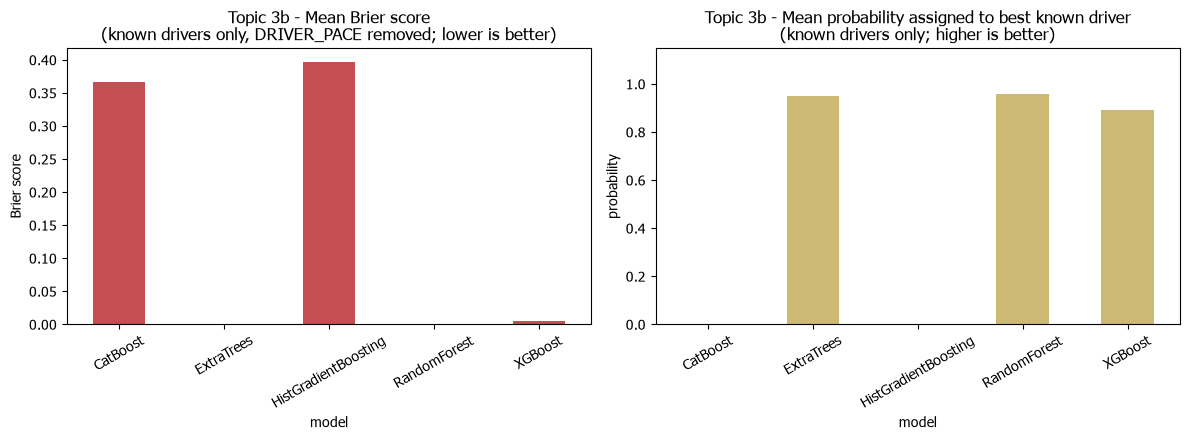

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

known_calibration_df["mean_brier"].plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("Topic 3b - Mean Brier score\n(known drivers only, DRIVER_PACE removed; lower is better)")
axes[0].set_ylabel("Brier score")

known_calibration_df["mean_prob_on_actual_winner"].plot(kind="bar", ax=axes[1], color="#CCB974")
axes[1].set_title("Topic 3b - Mean probability assigned to best known driver\n(known drivers only; higher is better)")
axes[1].set_ylabel("probability")
axes[1].set_ylim(0, max(0.3, known_calibration_df["mean_prob_on_actual_winner"].max() * 1.2))

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

##Brier score = "โมเดลทายผิดขนาดไหน" (นับทุกคนในกลุ่ม, ยิ่งใกล้ 0 ยิ่งดี, ยิ่งมั่นใจผิดยิ่งพัง)
##Probability on actual winner = "โมเดลให้คะแนนความมั่นใจกับคนที่ถูกจริงเท่าไหร่" (ยิ่งใกล้ 1 ยิ่งดี)


## 7. สรุปรวม 3 หัวข้อหลัก

Normalize แต่ละหัวข้อให้อยู่ในช่วง 0-1 (1 = ดีที่สุดในกลุ่ม) แล้ววาด radar chart เทียบทั้ง 5 โมเดลในคราวเดียว

In [43]:
summary = pd.DataFrame(index=list(MODELS.keys()))

summary["1. Accuracy"] = 1 - (
    (accuracy_df["MAE_sec"] - accuracy_df["MAE_sec"].min())
    / (accuracy_df["MAE_sec"].max() - accuracy_df["MAE_sec"].min() + 1e-9)
)
summary["2. Ranking"] = (ranking_df["mean_spearman"].clip(lower=0) + ranking_df["winner_hit_rate"]) / 2
summary["3. Calibration"] = 1 - (
    (calibration_df["mean_brier"] - calibration_df["mean_brier"].min())
    / (calibration_df["mean_brier"].max() - calibration_df["mean_brier"].min() + 1e-9)
)

summary


,1. Accuracy,2. Ranking,3. Calibration
RandomForest,1.000000e+00,0.833876,1.000000
ExtraTrees,8.469975e-02,0.832874,1.000000
HistGradientBoosting,6.997389e-10,0.827402,1.000000
XGBoost,8.271205e-01,0.834294,1.000000
CatBoost,7.755996e-01,0.826232,0.050198


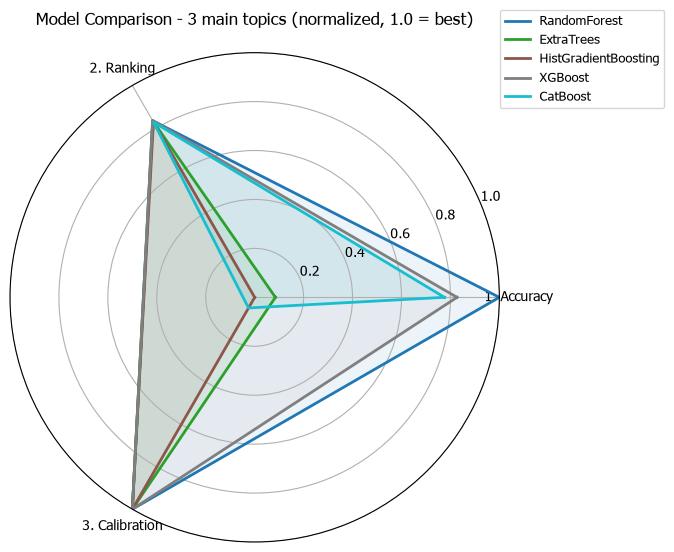

In [44]:
categories = list(summary.columns)
n = len(categories)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(summary)))

for (name, row), color in zip(summary.iterrows(), colors):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=name, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title("Model Comparison - 3 main topics (normalized, 1.0 = best)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()


### 7.1 Weighted Decision Matrix

รวม 3 หัวข้อของแต่ละโมเดลให้เหลือ **คะแนนเดียว (Weighted Score)** เพื่อจัดอันดับโมเดลที่เหมาะกับการเอาไปใช้จริงที่สุด
ปรับน้ำหนักได้ที่ `WEIGHTS` ด้านล่าง (ค่าเริ่มต้นให้น้ำหนักเท่ากันทั้ง 3 หัวข้อ — ถ้าสนใจเรื่องอันดับ/win probability ของหน้า Forecast
มากกว่าความแม่นตัวเลขดิบๆ ก็เพิ่มน้ำหนักหัวข้อ 2-3 ได้)

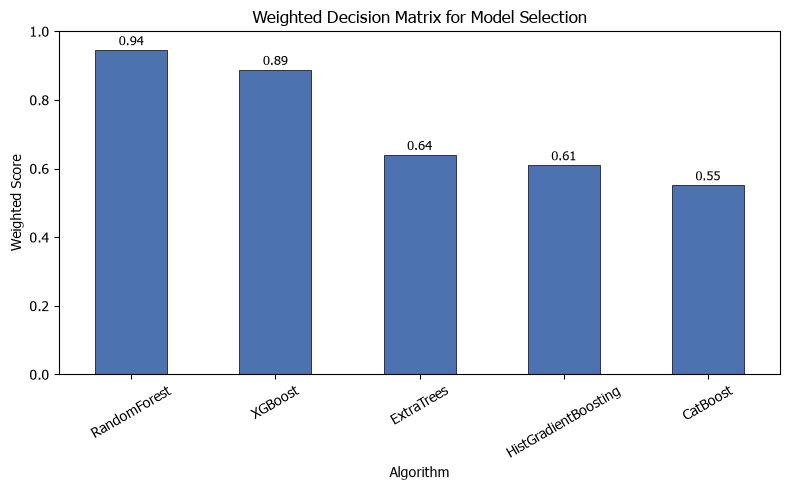

,weighted_score
RandomForest,0.944625
XGBoost,0.887138
ExtraTrees,0.639191
HistGradientBoosting,0.609134
CatBoost,0.550677


In [45]:
WEIGHTS = {
    "1. Accuracy": 1 / 3,
    "2. Ranking": 1 / 3,
    "3. Calibration": 1 / 3,
}

weighted_score = (summary * pd.Series(WEIGHTS)).sum(axis=1)
weighted_score = weighted_score.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
weighted_score.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="black", linewidth=0.5)
ax.set_title("Weighted Decision Matrix for Model Selection")
ax.set_ylabel("Weighted Score")
ax.set_xlabel("Algorithm")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
for i, v in enumerate(weighted_score):
    ax.text(i, v + 0.015, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

weighted_score.to_frame("weighted_score")


In [46]:
# ตารางสรุปเต็ม (รวม train_time และ weighted_score เป็นข้อมูลอ้างอิงเสริม) + บันทึกเป็น CSV
full_report = (
    accuracy_df.join(ranking_df).join(calibration_df).join(train_time_df)
    .join(weighted_score.rename("weighted_score"))
    .sort_values("weighted_score", ascending=False)
)
full_report.to_csv("model_comparison_report.csv")
print("saved -> model_comparison_report.csv")
full_report


saved -> model_comparison_report.csv


,MAE_sec,RMSE_sec,R2,winner_hit_rate,mean_top3_overlap,mean_spearman,mean_brier,mean_prob_on_actual_winner,train_time_sec,weighted_score
model,,,,,,,,,,
RandomForest,1.825461,4.649156,0.791905,1.0,0.555556,0.667753,5.703750e-18,1.000000,0.404513,0.944625
XGBoost,2.072523,4.854824,0.773087,1.0,0.555556,0.668588,1.551842e-17,1.000000,0.244236,0.887138
ExtraTrees,3.133520,7.697982,0.429485,1.0,0.555556,0.665748,1.436815e-17,1.000000,0.247429,0.639191
HistGradientBoosting,3.254565,5.769609,0.679516,1.0,0.444444,0.654804,1.317128e-16,1.000000,0.409483,0.609134
CatBoost,2.146152,4.703937,0.786972,1.0,0.555556,0.652464,1.892104e-08,0.999657,1.077352,0.550677


## หมายเหตุ

- Hyperparameter ของแต่ละโมเดลตั้งให้ "จำนวนต้นไม้/รอบ iteration" ใกล้เคียงกัน (~500) เพื่อความยุติธรรมเบื้องต้น
  หากต้องการเทียบ "ศักยภาพสูงสุด" ของแต่ละอัลกอริทึมจริงๆ ควรทำ hyperparameter tuning (เช่น `RandomizedSearchCV`) แยกทีละโมเดลเพิ่มเติม
- `HOLDOUT_RACES` ตั้งเป็น Monaco / British / Italian 2023 เพราะไม่อยู่ใน `TRAIN_COMBINATIONS` เลย — เพิ่ม/เปลี่ยนสนามได้ตาม
  `AVAILABLE_RACES` ของ `data_pipeline.py` เพื่อให้ผลหัวข้อที่ 2-3 เสถียรขึ้น (ยิ่งหลายสนามยิ่งวัด ranking/calibration ได้แม่นขึ้น)
- หัวข้อที่ 2-3 จำลองทั้งสนาม (20 คัน) ด้วย `DRIVER_PACE` คงที่ต่อคัน (เหมือน `race_simulator.py` ของโปรเจกต์หลัก) เพราะ
  `TRAIN_COMBINATIONS` มีข้อมูลแค่ 5 driver — โมเดลเองแยกฝีมือนักแข่งที่เหลือไม่ได้จาก one-hot จึงต้องพึ่ง pace offset ช่วย
- ถ้าต้องการโมเดลที่ดีที่สุดไปใช้แทน `model.pkl` เดิม ให้เลือกจาก `trained_models[<ชื่อโมเดล>]` แล้ว pickle ออกมาในรูปแบบเดียวกับ
  `train_model_advanced.py` (`{"model":..., "features":..., ...}`)